## Содержание:
* [Стационарность](#stacionary)
* [Преобразование Бокса-Кокса](#boxcox)
* [Модели для предсказания значений временного ряда](#predict)
* [Метрики точности прогноза](#metrics)

Импортируем библиотеки

In [6]:
# Импортируем необходимые библиотеки

import os
from os import path
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.tsa.api as smt

Рутина с датасетами

In [7]:
# загрузите данные о пассажирах
passengers = pd.read_csv('passengers.csv')
# неподходящий формат данных приводим к тому, с которым Pandas может работать
passengers['Month'] = pd.to_datetime(passengers['Month'])
# также устанавливаем индекс и сортируем
df = passengers.set_index('Month').sort_index()

In [8]:
df.describe()

,Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


Отрисовываем временной ряд

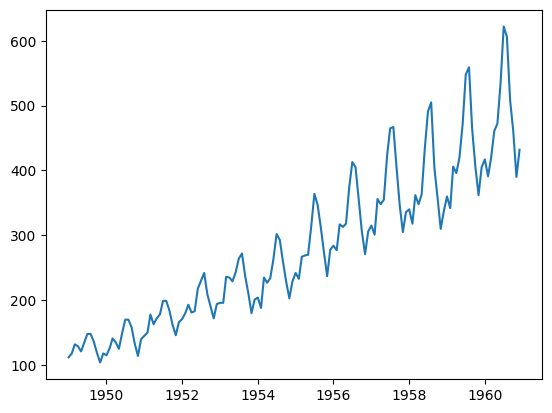

In [9]:
plt.plot(df["Passengers"])

## Стационарный процесс  <a class="anchor" id="stacionary"></a>

Стационарный процесс - это случайный процесс, безусловное совместное распределение вероятностей которого не изменяется при сдвиге во времени. Следовательно, такие параметры, как среднее значение и дисперсия, также не меняются со временем, поэтому стационарные временные ряды легче прогнозировать.

Есть несколько способов установить, является ли временной ряд стационарным или нет, наиболее распространенными являются старая добрая визуализация, просмотр автокорреляции и выполнение статистических тестов.

Наиболее распространенным тестом является тест Дики-Фуллера (также называемый тест ADF), где нулевая гипотеза состоит в том, что временной ряд имеет единичный корень, другими словами, временной ряд не является стационарным.

Мы проверим, можно ли отвергнуть нулевую гипотезу, сравнив значение p с выбранным порогом (α), чтобы, если значение p меньше, мы могли отклонить нулевую гипотезу и предположить, что временной ряд с уверенностью является стационарным. уровень 1-α (технически мы просто не можем сказать, что это не так)

Временной ряд имеет единичный корень, или порядок интеграции один, если его первые разности образуют стационарный ряд. Это условие записывается как
$y_t\thicksim I(1)$ если ряд первых разностей $\triangle y_t=y_t-y_{t-1}$ является стационарным $\triangle y_t\thicksim I(0)$.

При помощи этого теста проверяют значение коэффициента $a$ в  авторегрессионном уравнении первого порядка AR(1)
$y_t=a\cdot y_{t-1}+\varepsilon_t,$
где $y_t$ — временной ряд, а $\varepsilon$— ошибка.

Если $a=1$, то процесс имеет единичный корень, в этом случае ряд $y_t$ не стационарен, является интегрированным временным рядом первого порядка $I(1)$. Если $|a|<1$, то ряд стационарный $I(0)$.


In [10]:
# импортируем функцию, описывающую тест Дики-Фуллера
from statsmodels.tsa.stattools import adfuller

In [11]:
# всю теорию, описанную выше, реализуем с помощью statsmodels для проверки
# временного ряда перевозок на стационарность

alpha = 0.05
name = "Пассажиры"

# определяем временной ряд отдельной переменной
ts = df["Passengers"]

print(f'Тест Дики-Фуллера ряда {name} :')
# определяем результат значения теста из библиотеки с учетом
dftest = adfuller(ts, autolag='AIC')
dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])

for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
print(dfoutput)

if dfoutput["p-value"] < alpha:
    print(f"Значение p меньше {alpha * 100}%. Ряд стационарный.")
else:
    print(f"Значение p больше {alpha*100}%. Ряд не стационарный.")

Тест Дики-Фуллера ряда Пассажиры :
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64
Значение p больше 5.0%. Ряд не стационарный.


А теперь попробуем осуществить дифференцирование. Перед этим опять попробуем декомпозицию ряда.

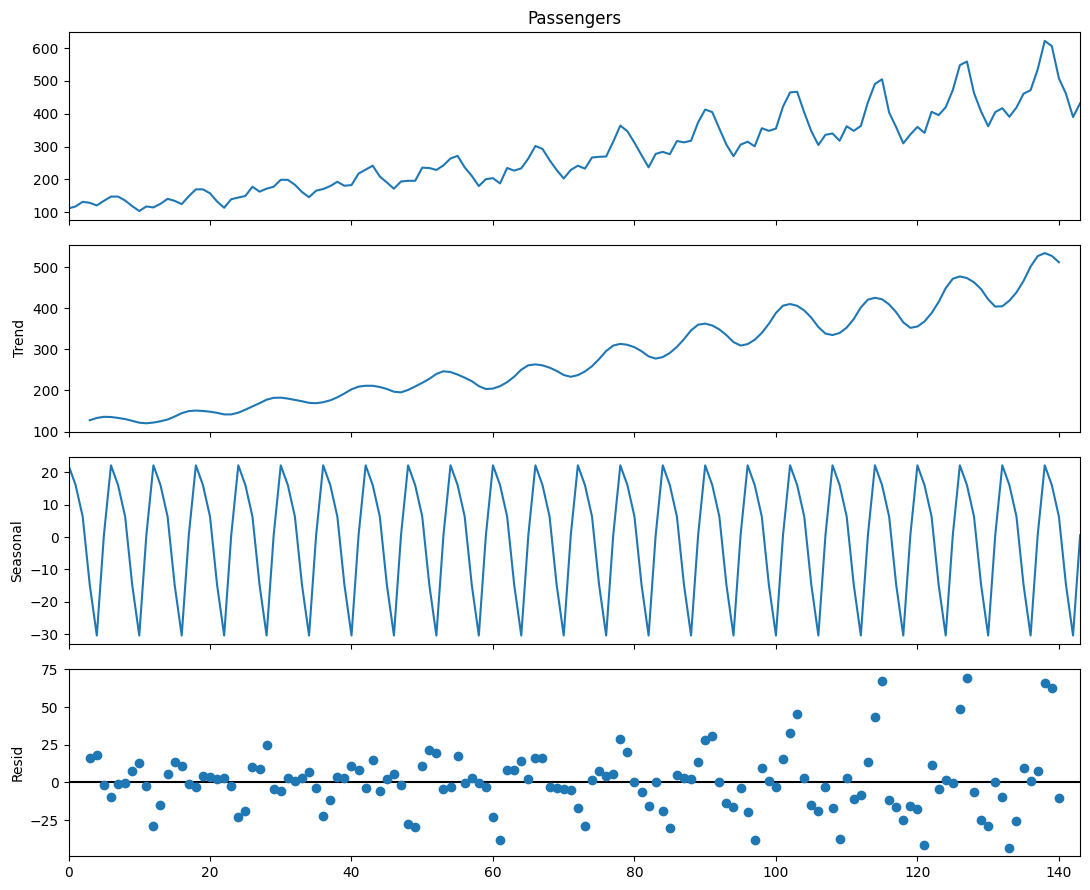

In [12]:
# импортируем функцию seasonal_decompose из statsmodels
# (то есть осуществляем декомпозицию сигнала/временного ряда)
from statsmodels.tsa.seasonal import seasonal_decompose

# задаем размер графика
from pylab import rcParams
rcParams['figure.figsize'] = 11, 9


# примените функцию seasonal_decompose к данным о перевозках
decompose = seasonal_decompose(passengers["Passengers"],
                               period=6)
decompose.plot()
plt.show()

Создадим два временных ряда на основе имеющегося, только без тренда и сезонности.

Удаляем тренд согласно формуле: $y' = y_t - y_{t-1}$;

Удаляем сезонность согласно формуле: $y' = y_t - y_{t-s}$;

In [13]:
nottrend = []
s = 6
notseason = []

# выборка без тренда
for i in range(1, len(df["Passengers"])):
   nottrend.append(df["Passengers"][i] - df["Passengers"][i-1])

# выборка без сезонности
for i in range(s, len(df["Passengers"])):
   notseason.append(df["Passengers"][i] - df["Passengers"][i-s])


/tmp/ipykernel_1955/105335193.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nottrend.append(df["Passengers"][i] - df["Passengers"][i-1])
/tmp/ipykernel_1955/105335193.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  notseason.append(df["Passengers"][i] - df["Passengers"][i-s])


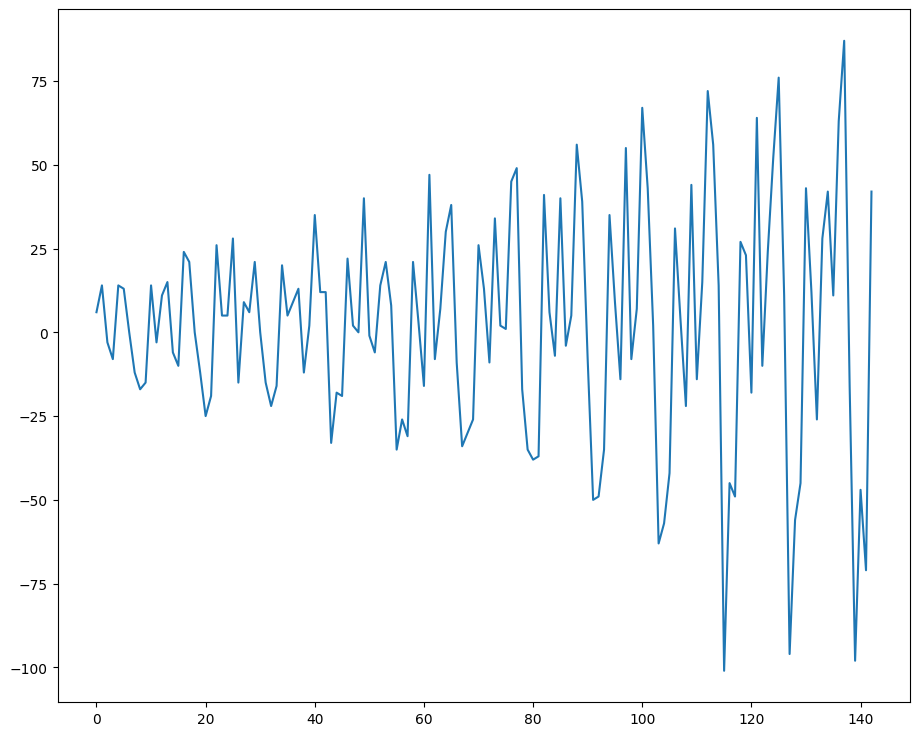

In [14]:
# отрисовываем временной ряд без тренда
plt.plot(nottrend)

Теперь проведем тест Дики-Фуллера на временном ряде без тренда

In [15]:
alpha = 0.05
name = "Пассажиры без тренда"

ts = nottrend

print(f'Тест Дики-Фуллера ряда {name} :')
dftest = adfuller(ts, autolag='AIC')
dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])

for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
print(dfoutput)

if dfoutput["p-value"] < alpha:
    print(f"Значение p меньше {alpha * 100}%. Ряд стационарный.")
else:
    print(f"Значение p больше {alpha*100}%. Ряд не стационарный.")

Тест Дики-Фуллера ряда Пассажиры без тренда :
Test Statistic                  -2.829267
p-value                          0.054213
#Lags Used                      12.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64
Значение p больше 5.0%. Ряд не стационарный.


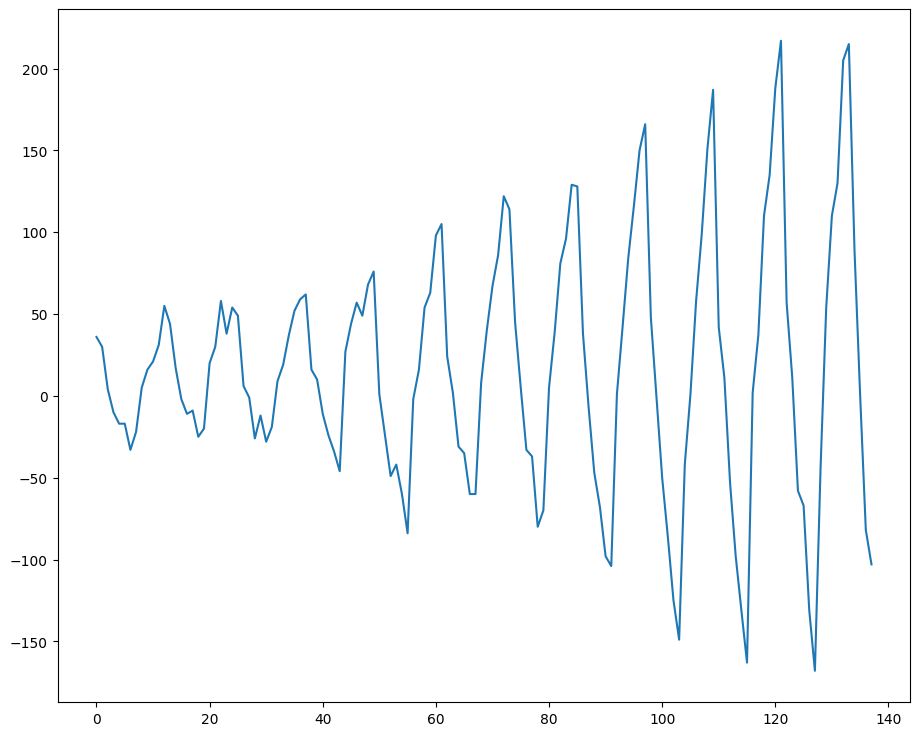

In [16]:
# отрисовываем временной ряд без сезонности
plt.plot(notseason)

Аналогичным образом проведем тест Дики-Фуллера на временном ряде без сезонности

In [17]:
alpha = 0.05
name = "Пассажиры без сезона"

ts = notseason

print(f'Тест Дики-Фуллера ряда {name} :')
dftest = adfuller(ts, autolag='AIC')
dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])

for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
print(dfoutput)

if dfoutput["p-value"] < alpha:
    print(f"Значение p меньше {alpha * 100}%. Ряд стационарный.")
else:
    print(f"Значение p больше {alpha*100}%. Ряд не стационарный.")

Тест Дики-Фуллера ряда Пассажиры без сезона :
Test Statistic                  -3.154446
p-value                          0.022778
#Lags Used                       7.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64
Значение p меньше 5.0%. Ряд стационарный.


## Преобразование Бокса-Кокса <a class="anchor" id="boxcox"></a>

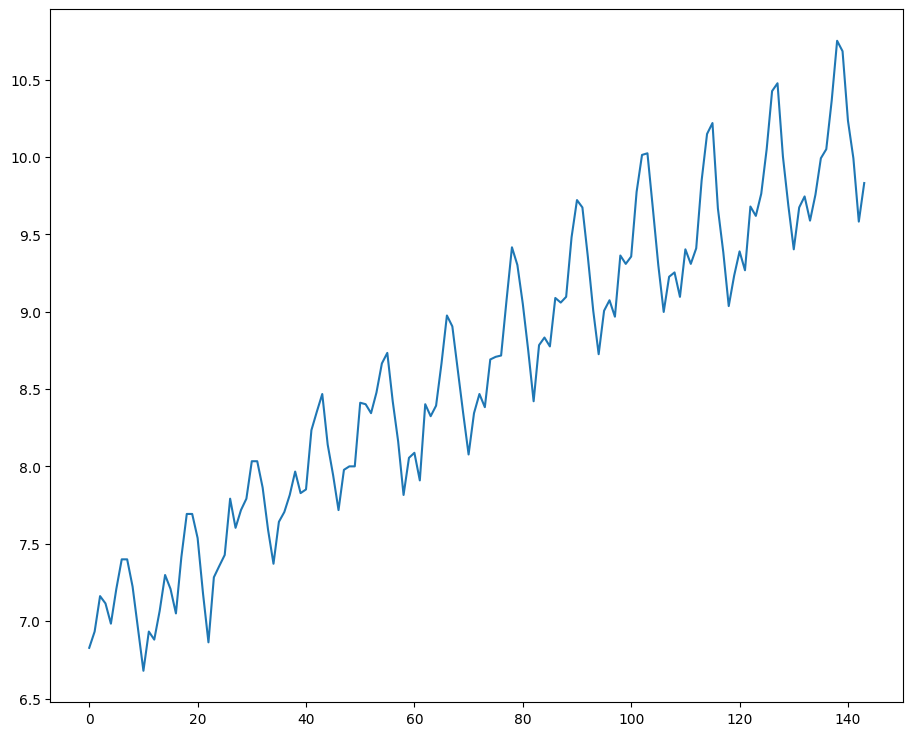

In [18]:
# Преобразование Бокса-Кокса
from scipy.stats import boxcox

# вызываем функцию преобразования, которая выдает преобразованные данные и
# лучший параметр лямбда, который обеспечивает близость к нормальному
# распределению
transformed_data, best_lambda = boxcox(df["Passengers"])

# а теперь посмотрим на преобразованные данные
plt.plot(transformed_data)

Попробуем теперь из преобразованного временного ряда удалить тренд и
визуализировать его

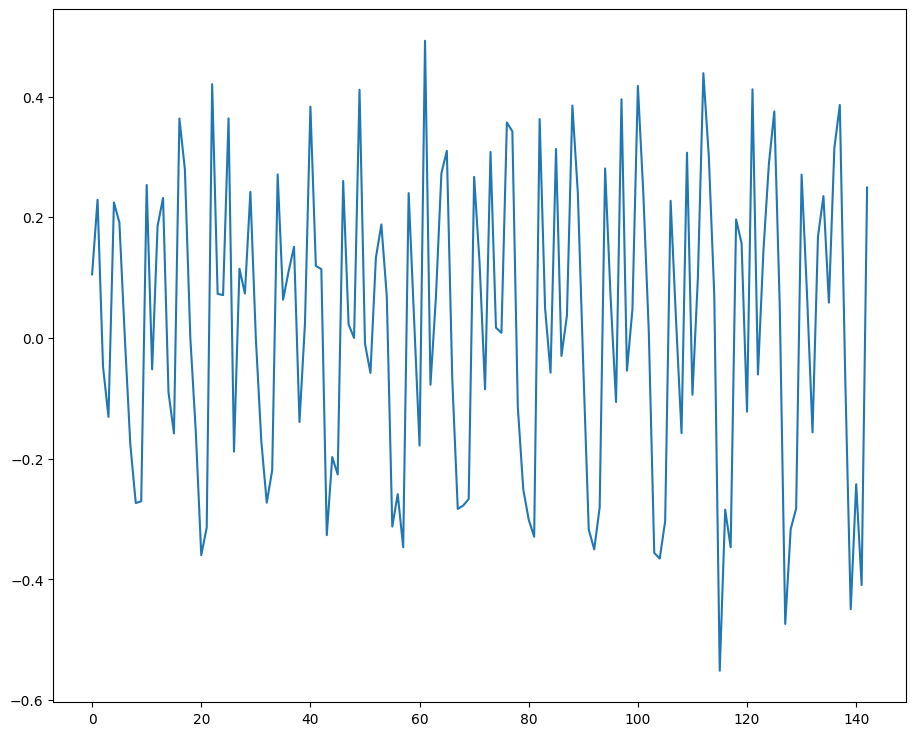

In [19]:
pnottrend = []

for i in range(1, len(transformed_data)):
   pnottrend.append(transformed_data[i] - transformed_data[i-1])


plt.plot(pnottrend)

Удалив тренд из преобразованного Боксом-Коксом ряда, попробуем опять проверить его на стационарность. Что-то изменилось?

In [20]:
alpha = 0.05
name = "Пассажиры после Кокса-Бокса"

ts = pnottrend

print(f'Тест Дики-Фуллера ряда {name} :')
dftest = adfuller(ts, autolag='AIC')
dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])

for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
print(dfoutput)

if dfoutput["p-value"] < alpha:
    print(f"Значение p меньше {alpha * 100}%. Ряд стационарный.")
else:
    print(f"Значение p больше {alpha*100}%. Ряд не стационарный.")

Тест Дики-Фуллера ряда Пассажиры после Кокса-Бокса :
Test Statistic                  -2.871708
p-value                          0.048738
#Lags Used                      14.000000
Number of Observations Used    128.000000
Critical Value (1%)             -3.482501
Critical Value (5%)             -2.884398
Critical Value (10%)            -2.578960
dtype: float64
Значение p меньше 5.0%. Ряд стационарный.


## Модели для предсказания значений временного ряда <a class="anchor" id="predict"></a>

Первой моделью будет модель **AR**, или же autoregression - модель, которая использует связь между наблюдением и некоторым количеством предыдущих наблюдений.​

Сделаем случайный ряд и затем поработаем с ним.

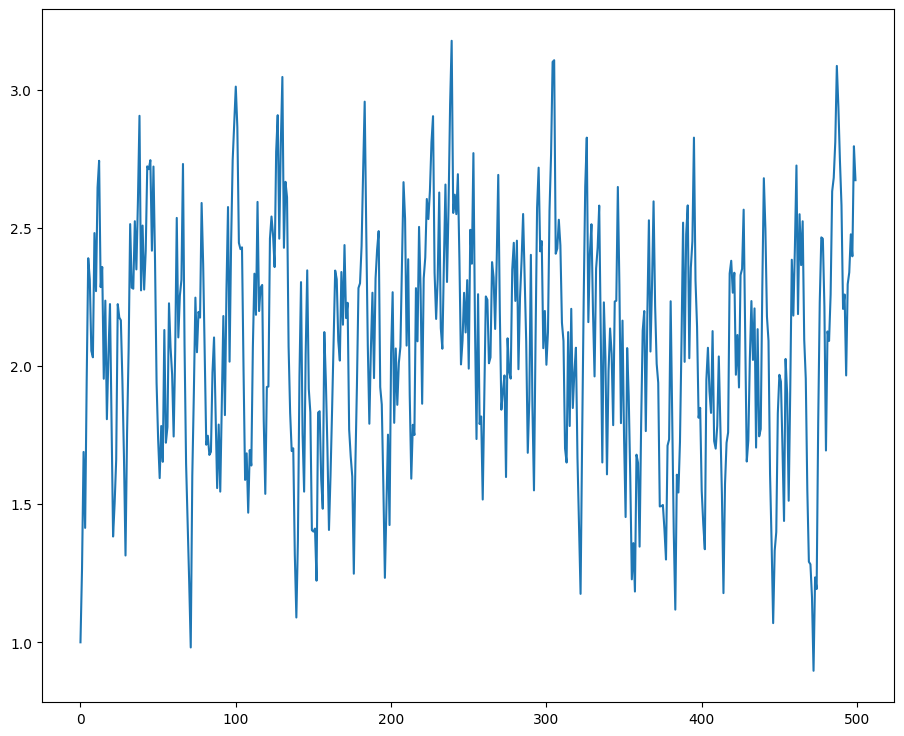

In [21]:
# AR(1)

N = 500

ar1 = [1]

for i in range(1, N):
    ar1.append(0.76 * ar1[i-1] + np.random.random())

plt.plot(ar1)

Посмотрим какие у него стандартное отклонение и среднее.

In [22]:
print(f"standart deviation = {np.std(ar1)}\n mean = {np.mean(ar1)}")

standart deviation = 0.4256200980394546
 mean = 2.075926980834395


А теперь обернем его в датафрейм и посмотрим его обычную и частичную автокорреляцию. Что можно сказать по поводу этого временного ряда, глядя на эти параметры?

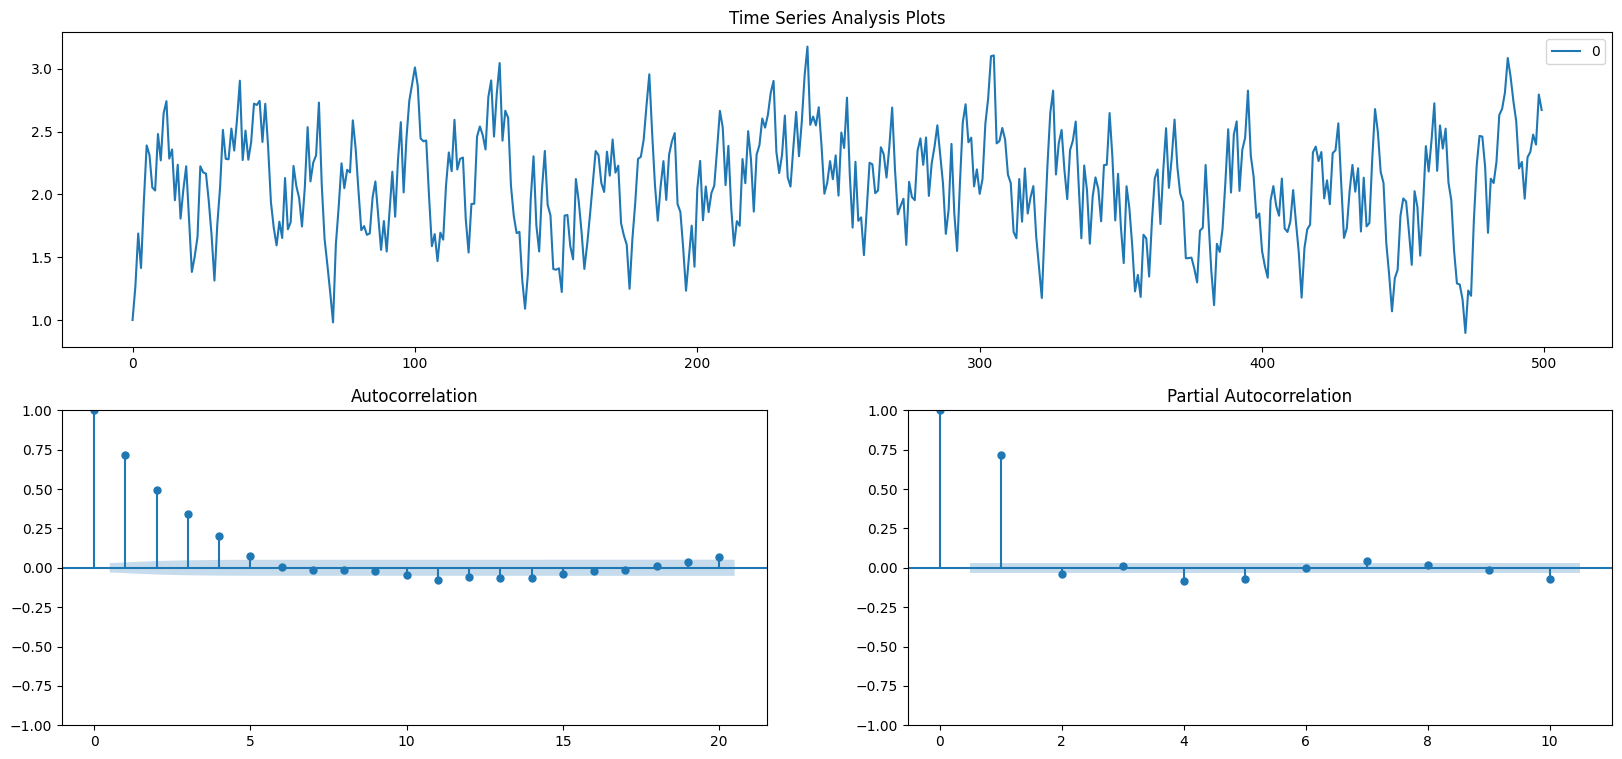

In [23]:
ts = pd.DataFrame(ar1)

fig = plt.figure(figsize=(20, 9))
layout = (2, 2)
ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
acf_ax = plt.subplot2grid(layout, (1, 0))
pacf_ax = plt.subplot2grid(layout, (1, 1))

ts.plot(ax=ts_ax)
ts_ax.set_title('Time Series Analysis Plots')
smt.graphics.plot_acf(ts, lags=20, ax=acf_ax, alpha=0.5)
smt.graphics.plot_pacf(ts, lags=10, ax=pacf_ax, alpha=0.5)
None

Сделаем ещё один случайный ряд, но уже и с отрицательными значениями коэффициента

standart deviation = 0.4536903834117316
 mean = 0.2995038508387999


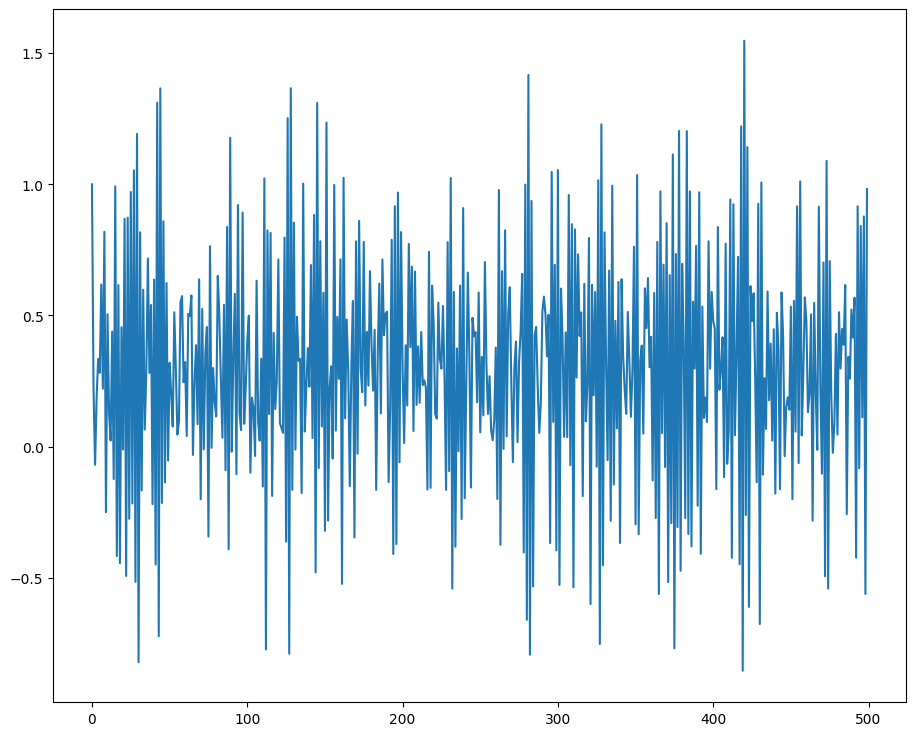

In [24]:
# AR(1)

N = 500

ar2 = [1]

for i in range(1, N):
    ar2.append(- 0.76*ar2[i-1] + np.random.random())

plt.plot(ar2)

print(f"standart deviation = {np.std(ar2)}\n mean = {np.mean(ar2)}")

А что можно сказать по поводу этого ряда?

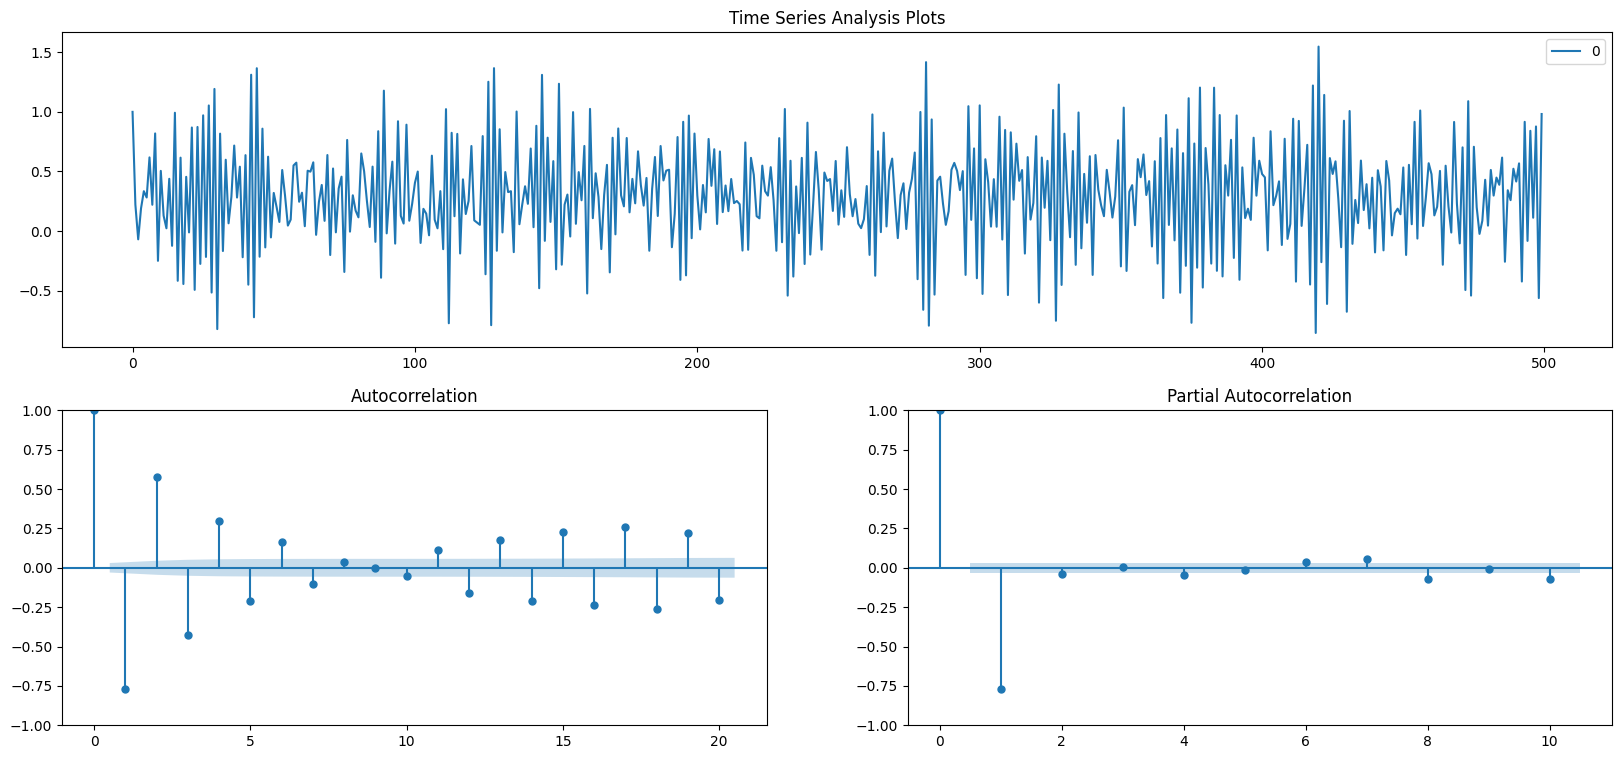

In [25]:
ts = pd.DataFrame(ar2)

fig = plt.figure(figsize=(20, 9))
layout = (2, 2)
ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
acf_ax = plt.subplot2grid(layout, (1, 0))
pacf_ax = plt.subplot2grid(layout, (1, 1))

ts.plot(ax=ts_ax)
ts_ax.set_title('Time Series Analysis Plots')
smt.graphics.plot_acf(ts, lags=20, ax=acf_ax, alpha=0.5)
smt.graphics.plot_pacf(ts, lags=10, ax=pacf_ax, alpha=0.5)
None

А теперь коэффициент >1

standart deviation = 0.4536903834117316
 mean = 0.2995038508387999


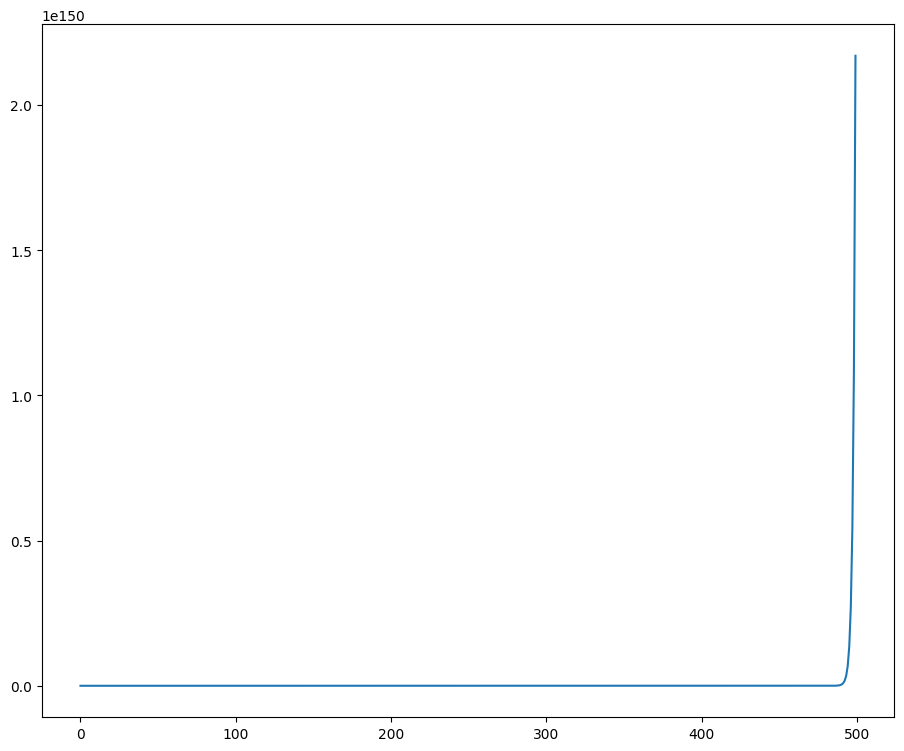

In [26]:
# AR(1)

N = 500

ar3 = [1]

for i in range(1, N):
    ar3.append(2 * ar3[i-1] + np.random.random())

plt.plot(ar3)

print(f"standart deviation = {np.std(ar2)}\n mean = {np.mean(ar2)}")

Ладно, пора возвращаться к прогнозированию. Следаем прогноз с помощью AR модели, предварительно поделив выборки на обучающую, валидационную и тестовую.

In [27]:
df = pd.read_csv('data/passengers.csv', names=["n","x"], skiprows=1)


df['t'] = df.index.values

ln = len(df)

# указываем 'объемы' выборок
train_cutoff = int(round(ln*0.75, 0))
validate_cutoff = int(round(ln*0.90,0))

# делим выборки
train_df = df[df['t'] <= train_cutoff]
validate_df = df[(df['t'] > train_cutoff) & (df['t'] <= validate_cutoff)]
forecast_df = df[df['t'] > validate_cutoff]

Визуализируем поделенные выборки.

* Обучающая выборка - синим цветом
* Валидационная выборка - оранжевым цветом
* Предсказываемая выборка - зеленым цветом

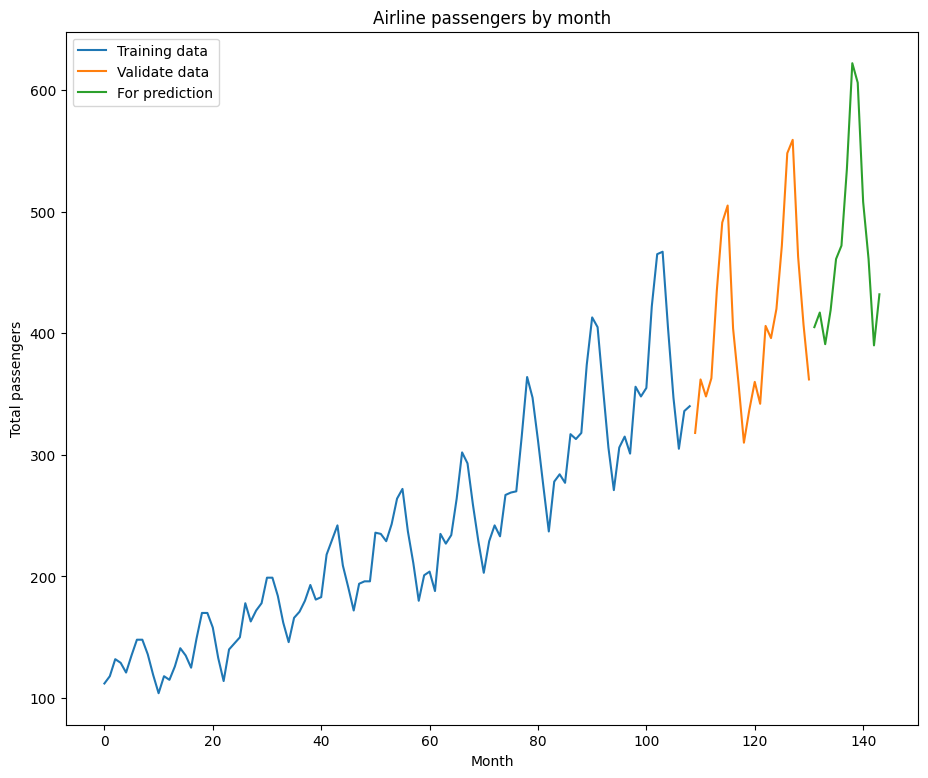

In [28]:
plt.plot(train_df.t, train_df.x, label='Training data')
plt.plot(validate_df.t, validate_df.x, label='Validate data')
plt.plot(forecast_df.t, forecast_df.x, label='For prediction')
plt.legend()
plt.title('Airline passengers by month')
plt.ylabel('Total passengers')
plt.xlabel('Month')
plt.show()

In [29]:
from statsmodels.tsa.ar_model import AutoReg, ar_select_order

In [30]:
# создаем объект модели на основе данных временного ряда с 3 лагами
mod = AutoReg(df.t, 3, old_names=False)
# обучаем
res = mod.fit()

# выводим сводку информации об авторегрессионной модели
print(res.summary())

                            AutoReg Model Results                             
Dep. Variable:                      t   No. Observations:                  144
Model:                     AutoReg(3)   Log Likelihood                3912.974
Method:               Conditional MLE   S.D. of innovations              0.000
Date:                Tue, 26 May 2026   AIC                          -7815.947
Time:                        15:27:27   BIC                          -7801.203
Sample:                             3   HQIC                         -7809.956
                                  144                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6667    1.2e-14   5.55e+13      0.000       0.667       0.667
t.L1           1.0000   1.19e-14   8.41e+13      0.000       1.000       1.000
t.L2           0.3333   1.47e-16   2.27e+15      0.0

In [31]:
# опять обучаем модель, но на этот раз указываем тип ковариационной оценки
res = mod.fit(cov_type="HC0")

# смотрим, что изменилось
print(res.summary())

                            AutoReg Model Results                             
Dep. Variable:                      t   No. Observations:                  144
Model:                     AutoReg(3)   Log Likelihood                3912.974
Method:               Conditional MLE   S.D. of innovations              0.000
Date:                Tue, 26 May 2026   AIC                          -7815.947
Time:                        15:27:27   BIC                          -7801.203
Sample:                             3   HQIC                         -7809.956
                                  144                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6667   7.71e-15   8.65e+13      0.000       0.667       0.667
t.L1           1.0000   7.57e-15   1.32e+14      0.000       1.000       1.000
t.L2           0.3333   1.61e-16   2.07e+15      0.0

Продолжаем экспериментировать

In [32]:
sel = ar_select_order(df.x, 13, old_names=False)
sel.ar_lags
res = sel.model.fit()
print(res.summary())

                            AutoReg Model Results                             
Dep. Variable:                      x   No. Observations:                  144
Model:                    AutoReg(13)   Log Likelihood                -497.994
Method:               Conditional MLE   S.D. of innovations             10.832
Date:                Tue, 26 May 2026   AIC                           1025.988
Time:                        15:27:27   BIC                           1069.116
Sample:                            13   HQIC                          1043.513
                                  144                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.1490      2.857      1.802      0.072      -0.451      10.749
x.L1           0.7608      0.070     10.885      0.000       0.624       0.898
x.L2          -0.0853      0.069     -1.229      0.2

Смотрим, что он предсказал

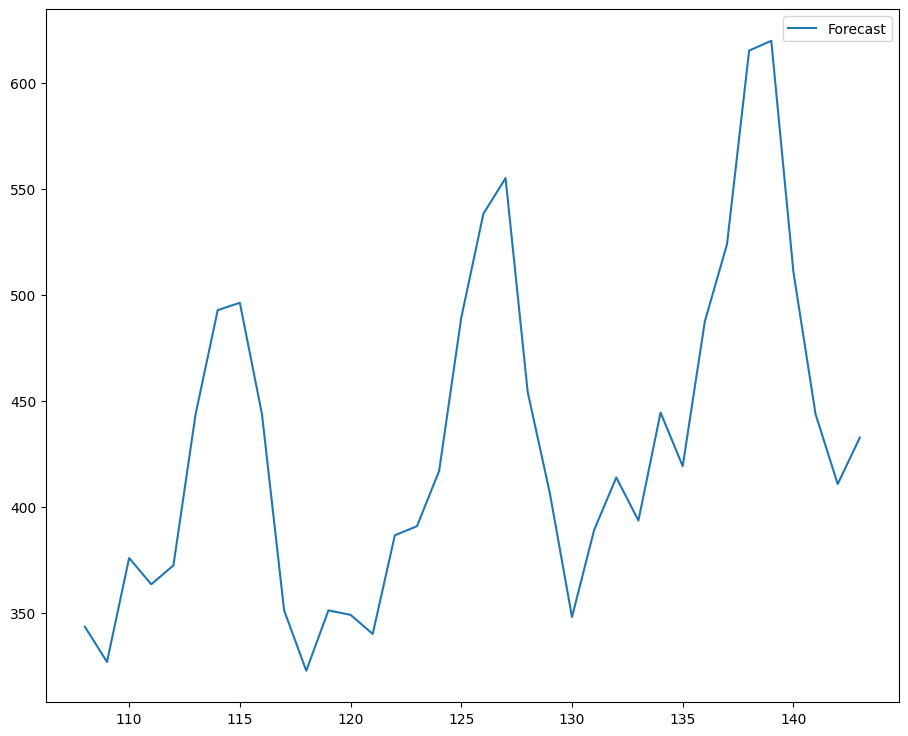

In [33]:
fig = res.plot_predict(train_cutoff)

Формируем предсказанные временные ряды

In [34]:
pred = res.predict(start=0, end=train_cutoff, dynamic=False)
v_pred = res.predict(start=train_cutoff+1, end=(validate_cutoff), dynamic=False)
f_pred = res.predict(start=validate_cutoff + 1, end=(forecast_df.t[len(df.t)-1]), dynamic=False)

Отрисовываем их

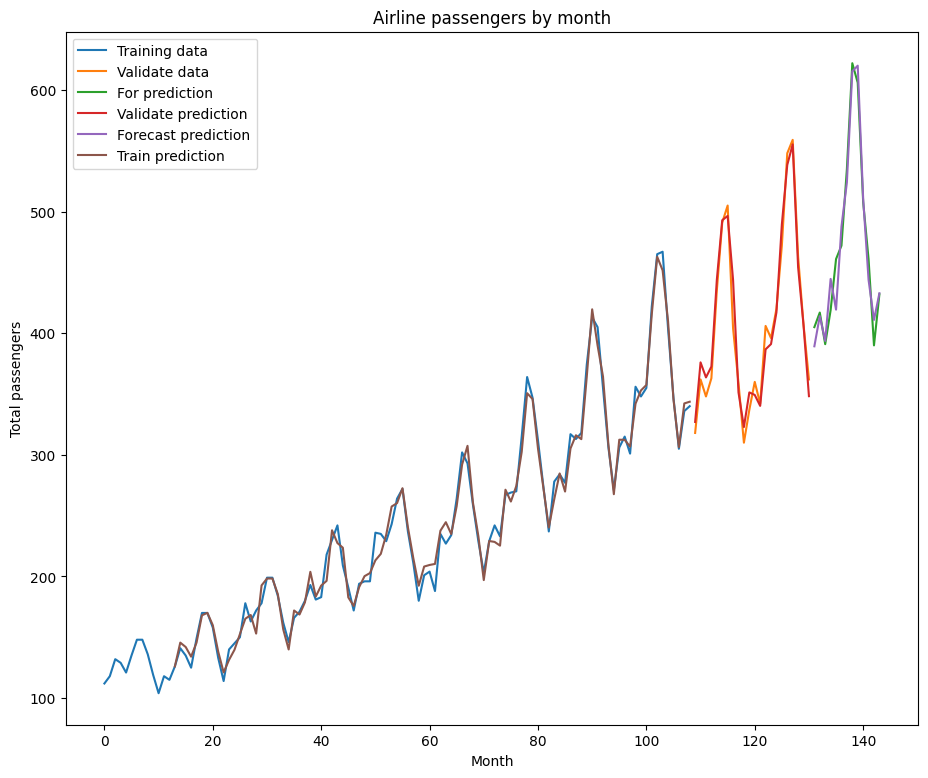

In [35]:
plt.plot(train_df.t, train_df.x, label='Training data')
plt.plot(validate_df.t, validate_df.x, label='Validate data')
plt.plot(forecast_df.t, forecast_df.x, label='For prediction')
plt.plot(validate_df.t, v_pred, label='Validate prediction ')
plt.plot(forecast_df.t, f_pred, label='Forecast prediction')
plt.plot(train_df.t, pred, label='Train prediction')

plt.legend()
plt.title('Airline passengers by month')
plt.ylabel('Total passengers')
plt.xlabel('Month')
plt.show()

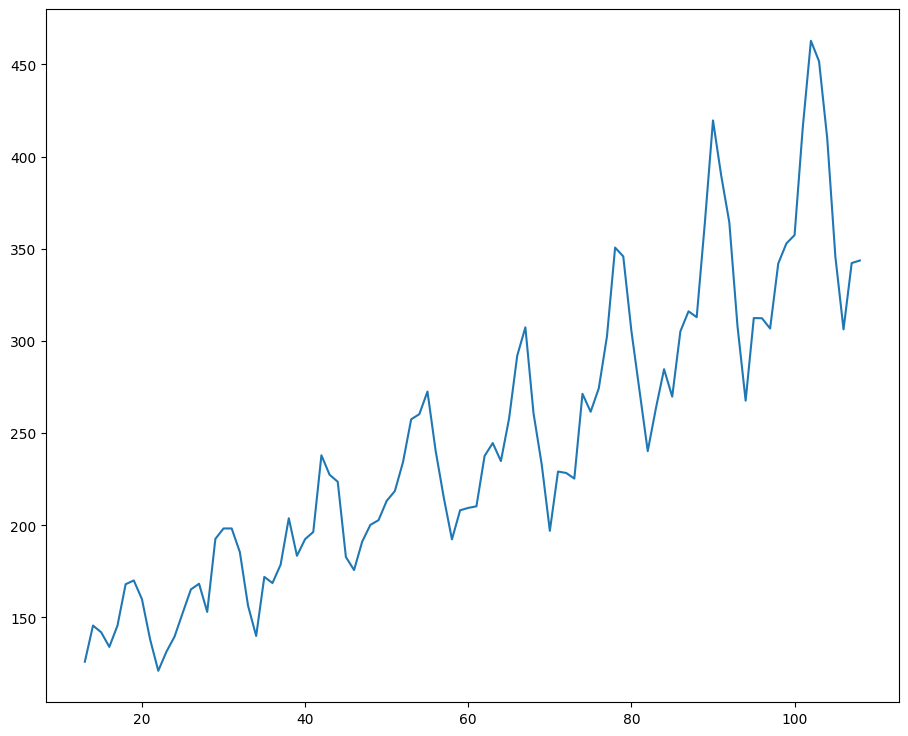

In [36]:
plt.plot(pred)

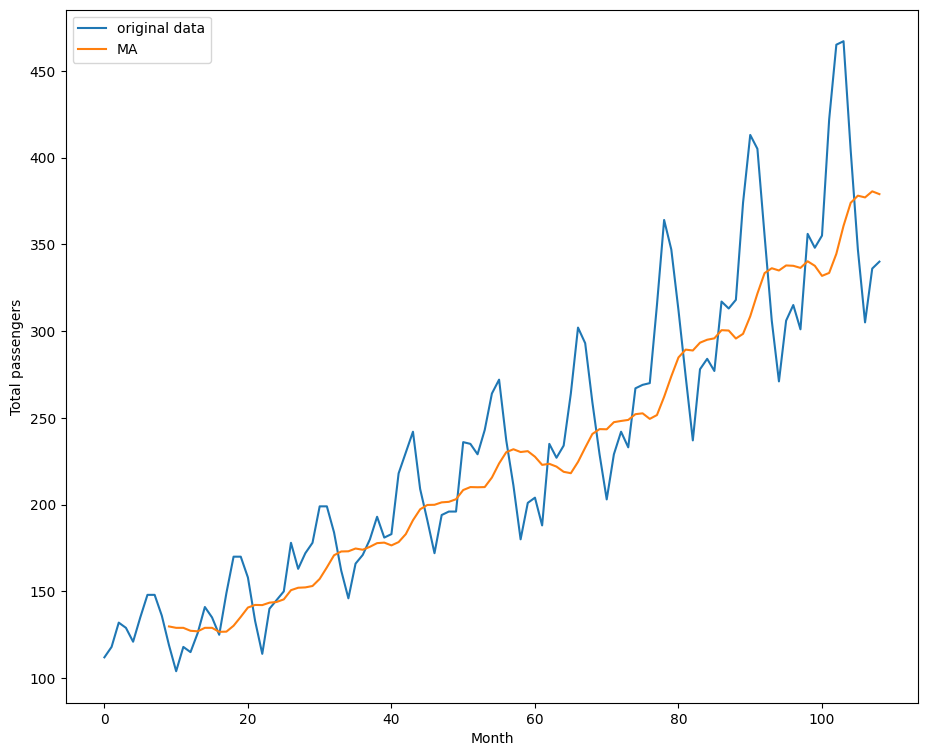

In [37]:
# MA

df['t'] = df.index.values

ln = len(df)

# указываем 'объемы' выборок
train_cutoff = int(round(ln*0.75, 0))
validate_cutoff = int(round(ln*0.90,0))

# делим выборки
train_df = df[df['t'] <= train_cutoff]
validate_df = df[(df['t'] > train_cutoff) & (df['t'] <= validate_cutoff)]
forecast_df = df[df['t'] > validate_cutoff]

plt.plot(train_df["t"], train_df["x"], label="original data")
plt.plot(train_df["t"], train_df["x"].rolling(10).mean(), label="MA")
plt.legend()
plt.ylabel('Total passengers')
plt.xlabel('Month')
plt.show()

## Метрики точности прогноза <a class="anchor" id="metrics"></a>

* R2- коэффициент детерминации     ​
* MSE (RMSE) – mean squared error – среднеквадратичная ошибка​
* MAE – mean absolute error – средняя абсолютная ошибка​
* MAPE – mean absolute percentage error – средняя абсолютная ошибка в %​
* SMAPE – symmetric mean absolute percentage error – симметричная средняя абсолютная ошибка в %

Определяем метрики точности прогноза из библиотеки sklearn. Попробуй определить последнюю оставшуюся метрику **SMAPE** самостоятельно.

In [38]:
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score

Вычислим значения ошибок модели AR, опираясь на предсказанные ею значения forecast.

In [39]:
print("RMSE:", np.sqrt(mean_squared_error(forecast_df.x, f_pred)))
print("MAPE:", mean_absolute_percentage_error(forecast_df.x, f_pred))
print("MAE:", mean_absolute_error(forecast_df.x, f_pred))
print("R2: ", r2_score(forecast_df.x, f_pred))

RMSE: 17.540788248085942
MAPE: 0.030039826361233028
MAE: 13.680314913378862
R2:  0.9437821578085052


# **Задание:** Изучить, как работает модель авторегрессии (AR) на временном ряду и оценить её качество.

In [40]:
# Простыми словами, нужно сделать задание по аналогии с тем нестационарным временным рядом (см. выше).

In [41]:


from statsmodels.tsa.arima_process import arma_generate_sample

np.random.seed(42)

# AR(2) процесс
ar_data = arma_generate_sample(
    ar=np.array([1.0, -0.5, 0.7]),
    ma=np.array([1]),
    nsample=200,
    scale=1,
    burnin=1000
)

time = np.arange(200)

trend = time * 0.2
seasonality = 2 * np.sin(2 * np.pi * time / 12)

time_series = trend + seasonality + ar_data

df = pd.DataFrame({
    "t": time,
    "x": time_series
})

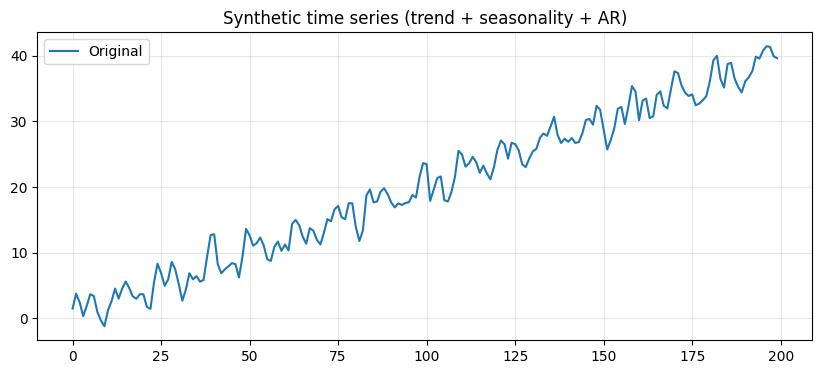

In [42]:
plt.figure(figsize=(10,4))
plt.plot(df.t, df.x, label="Original")
plt.title("Synthetic time series (trend + seasonality + AR)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

=== Тест Дики-Фуллера (исходный ряд) ===
Test Statistic                   0.336268
p-value                          0.978949
#Lags Used                      15.000000
Number of Observations Used    184.000000
Critical Value (1%)             -3.466398
Critical Value (5%)             -2.877380
Critical Value (10%)            -2.575214
dtype: float64
p-value > 5.0% => Ряд НЕ стационарный


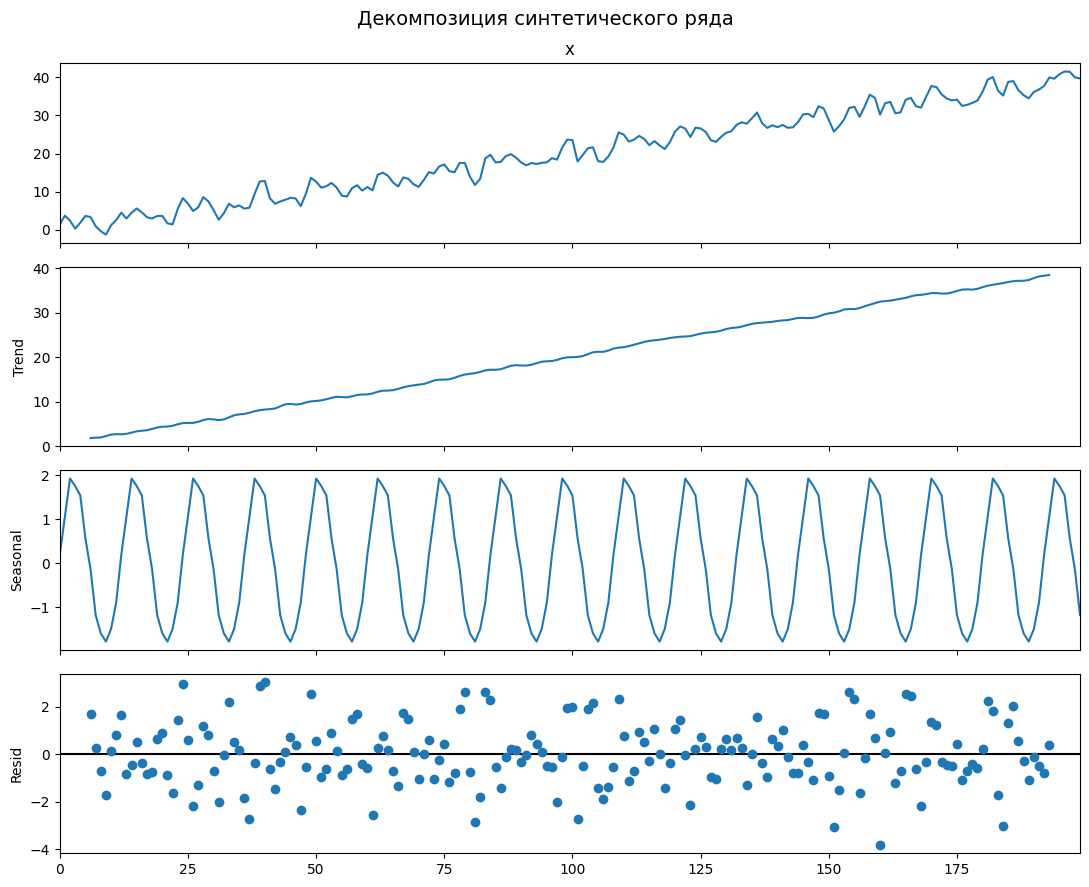

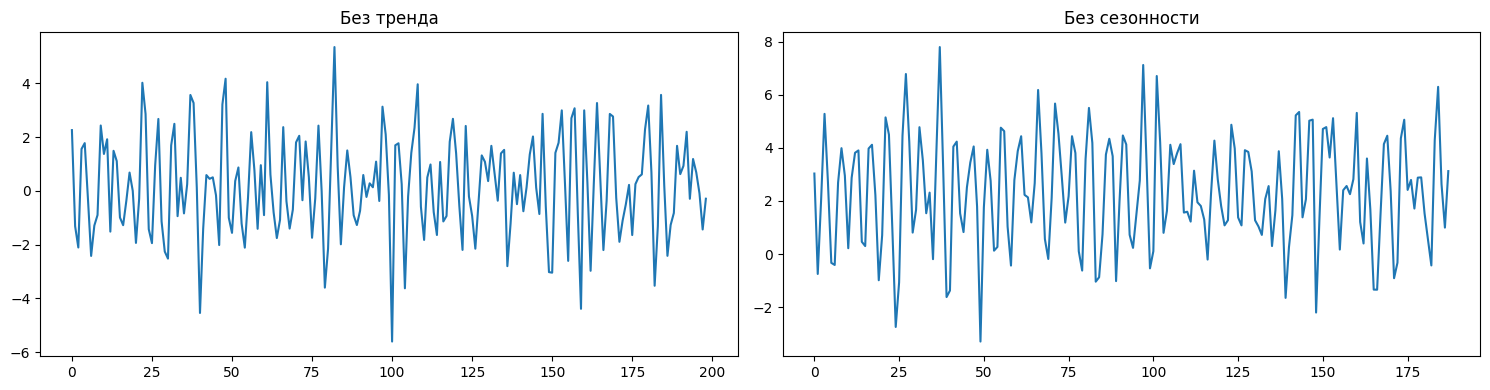


=== Тест Дики-Фуллера (без тренда) ===
Test Statistic                -8.097858e+00
p-value                        1.324108e-12
#Lags Used                     1.400000e+01
Number of Observations Used    1.840000e+02
Critical Value (1%)           -3.466398e+00
Critical Value (5%)           -2.877380e+00
Critical Value (10%)          -2.575214e+00
dtype: float64
p-value < 5.0% => Ряд стационарный


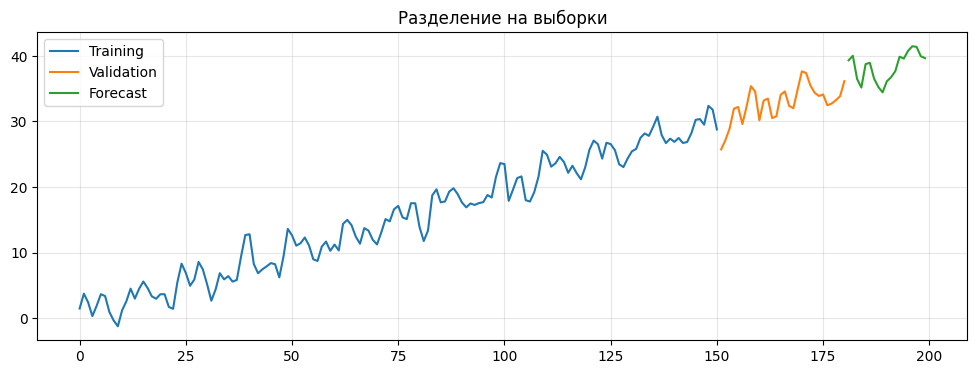


Выбранные лаги: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
                            AutoReg Model Results                             
Dep. Variable:                      x   No. Observations:                  200
Model:                    AutoReg(12)   Log Likelihood                -288.797
Method:               Conditional MLE   S.D. of innovations              1.124
Date:                Tue, 26 May 2026   AIC                            605.593
Time:                        15:27:31   BIC                            650.903
Sample:                            12   HQIC                           623.951
                                  200                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4421      0.202      7.139      0.000       1.046       1.838
x.L1           0.6488      0.069      9.389      0.000       0.513       0

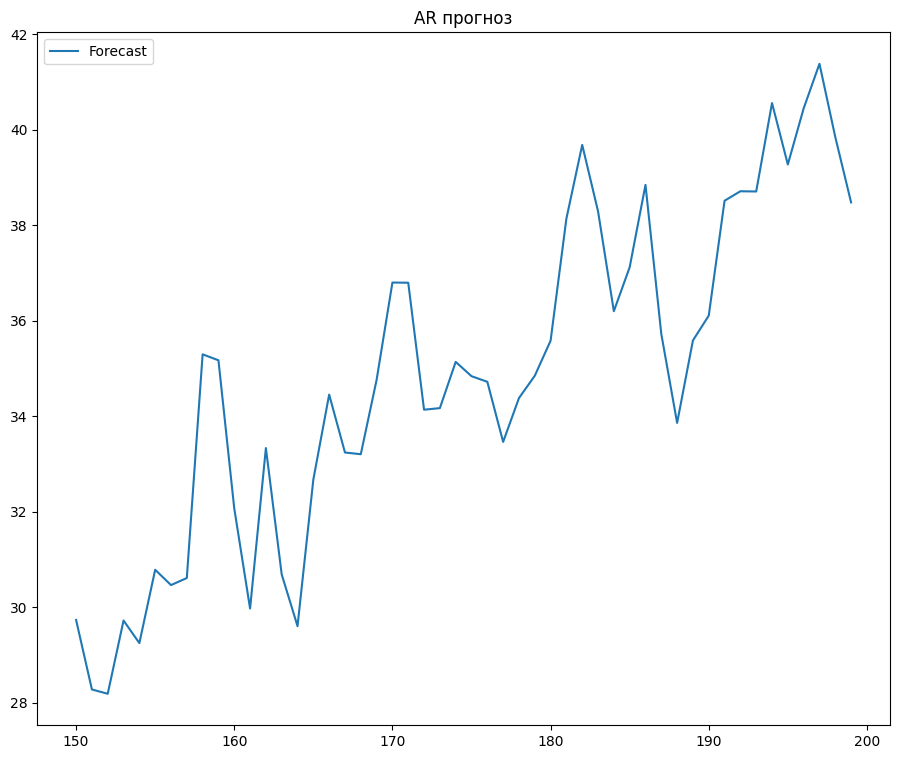

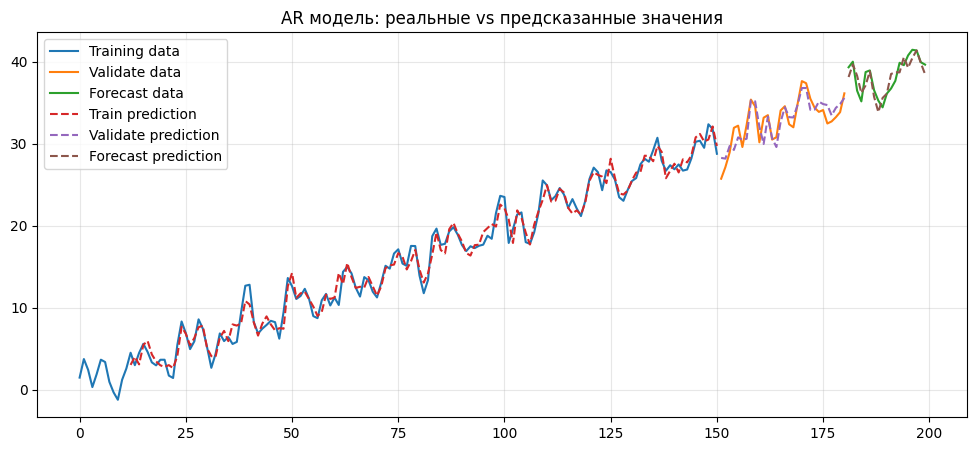


=== Метрики на forecast выборке ===
RMSE:  1.1151230355826083
MAPE:  0.025269555161250033
MAE:   0.9568579393713045
R2:    0.7278087289679414
SMAPE: 2.5286947070625247


In [43]:
significance_level = 0.05

print('=== Тест Дики-Фуллера (исходный ряд) ===')
adf_result = adfuller(df['x'], autolag='AIC')
stats_df = pd.Series(adf_result[:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
for k, v in adf_result[4].items():
    stats_df[f'Critical Value ({k})'] = v
print(stats_df)

if stats_df['p-value'] < significance_level:
    print(f'p-value < {significance_level*100}% => Ряд стационарный')
else:
    print(f'p-value > {significance_level*100}% => Ряд НЕ стационарный')


plt.rc('figure', figsize=(11, 9))
ts_decomposition = seasonal_decompose(df['x'], period=12)
ts_decomposition.plot()
plt.suptitle('Декомпозиция синтетического ряда', fontsize=14)
plt.tight_layout()
plt.show()


ts_vals = df['x'].values
detrended_data = [ts_vals[i] - ts_vals[i-1] for i in range(1, len(ts_vals))]

period = 12
deseasonalized_data = [ts_vals[i] - ts_vals[i-period] for i in range(period, len(ts_vals))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
ax1.plot(detrended_data)
ax1.set_title('Без тренда')
ax2.plot(deseasonalized_data)
ax2.set_title('Без сезонности')
plt.tight_layout()
plt.show()


print('\n=== Тест Дики-Фуллера (без тренда) ===')
adf_detrended = adfuller(detrended_data, autolag='AIC')
stats_detrended = pd.Series(adf_detrended[:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
for k, v in adf_detrended[4].items():
    stats_detrended[f'Critical Value ({k})'] = v
print(stats_detrended)

if stats_detrended['p-value'] < significance_level:
    print(f'p-value < {significance_level*100}% => Ряд стационарный')
else:
    print(f'p-value > {significance_level*100}% => Ряд НЕ стационарный')


total_size = len(df)
split_train = int(round(total_size * 0.75))
split_val = int(round(total_size * 0.90))

df_train = df[df['t'] <= split_train]
df_val = df[(df['t'] > split_train) & (df['t'] <= split_val)]
df_test = df[df['t'] > split_val]

plt.figure(figsize=(12, 4))
plt.plot(df_train['t'], df_train['x'], label='Training')
plt.plot(df_val['t'], df_val['x'], label='Validation')
plt.plot(df_test['t'], df_test['x'], label='Forecast')
plt.legend()
plt.title('Разделение на выборки')
plt.grid(alpha=0.3)
plt.show()


optimal_lags = ar_select_order(df['x'], 13, old_names=False)
print(f'\nВыбранные лаги: {optimal_lags.ar_lags}')
trained_ar = optimal_lags.model.fit()
print(trained_ar.summary())


trained_ar.plot_predict(split_train)
plt.title('AR прогноз')
plt.show()

p_train = trained_ar.predict(start=0, end=split_train, dynamic=False)
p_val = trained_ar.predict(start=split_train + 1, end=split_val, dynamic=False)
p_test = trained_ar.predict(start=split_val + 1, end=df_test['t'].iloc[-1], dynamic=False)

plt.figure(figsize=(12, 5))
plt.plot(df_train['t'], df_train['x'], label='Training data')
plt.plot(df_val['t'], df_val['x'], label='Validate data')
plt.plot(df_test['t'], df_test['x'], label='Forecast data')
plt.plot(df_train['t'], p_train, '--', label='Train prediction')
plt.plot(df_val['t'], p_val, '--', label='Validate prediction')
plt.plot(df_test['t'], p_test, '--', label='Forecast prediction')
plt.legend()
plt.title('AR модель: реальные vs предсказанные значения')
plt.grid(alpha=0.3)
plt.show()


def calc_smape(y_true, y_pred):
    numerator = np.abs(y_true - y_pred) * 2
    denominator = np.abs(y_true) + np.abs(y_pred)
    return np.mean(numerator / denominator) * 100

print('\n=== Метрики на forecast выборке ===')
print('RMSE: ', np.sqrt(mean_squared_error(df_test['x'], p_test)))
print('MAPE: ', mean_absolute_percentage_error(df_test['x'], p_test))
print('MAE:  ', mean_absolute_error(df_test['x'], p_test))
print('R2:   ', r2_score(df_test['x'], p_test))
print('SMAPE:', calc_smape(df_test['x'].values, p_test.values))